<a href="https://colab.research.google.com/github/sofiabilbaocr/Intro-a-datos/blob/main/Intro_a_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 0**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open ('hola.txt', 'r') as archivo:
  contenido = archivo.read()
  print(contenido)

FileNotFoundError: [Errno 2] No such file or directory: 'hola.txt'

In [ ]:
with open ('datos.json', 'r') as archivo:
  contenido = archivo.read()
  print(contenido)

In [ ]:
import csv

with open('datos.csv', newline='' ) as archivo:
  Reader = csv.reader(archivo)
  for i in Reader:
    print(i)



In [ ]:
import pandas as pd


df = pd.read_csv('datos.csv')

print(df)


In [ ]:
import pandas as pd

df = pd.read_json('datos.json')
print(df)

In [ ]:
import numpy as np

A = np.genfromtxt('hola.txt', dtype= 'str')
print(A)

B = np.genfromtxt('datos.csv', delimiter=',', dtype='str')
print(B)

In [ ]:
import numpy as np
import json

with open('datos.json', 'r') as f:
  data = json.load(f)

arr = np.array(data)
print(arr)


In [ ]:
pip install numpy


In [ ]:
pip install pillow


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

img_path = '/content/descarga.jpeg'

perro = Image.open(img_path)

image_array = np.array(perro)

print(f'image loaded into a numpy array with shape:{image_array.shape}')
print(f'Data type of the array: {image_array.dtype}')
print(f'image: {image_array}')


In [ ]:
import matplotlib.pyplot as plt

#Imagen a color
plt.figure(figsize=(6, 6))
plt.imshow(image_array)
plt.title('Imagen en Colores')
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Imagen blanco y negro
# For RGB images, a common way to convert to grayscale is to take the average of the RGB channels.
# Or use a weighted sum (e.g., ITU-R BT.601 standard: 0.2989*R + 0.5870*G + 0.1140*B)
grayscale_image_array = np.mean(image_array, axis=2).astype(np.uint8)

# Display the grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(grayscale_image_array, cmap='gray')
plt.title('Imagen en Blanco y Negro')
plt.axis('off')
plt.show()

# **Laboratorio 1**


##Resumen


Durante el laboratorio, se utilizó jupyter notebook y aplicaron tres métodos fundamentales para la gestión de datos. Se implementaron context managers (with open) para la lectura y escritura segura de archivos planos y CSV. También se utilizó la librería Pandas para procesar y exportar datos estructurados. Y por último, se utilizó Pickle para serializar y almacenar DataFrames conservando s sus tipos de datos.

**Ejercicio 1**



1. Lectura de archivosCSV y TXT usando context managers

In [ ]:
import csv

#Ruta como una variable
ruta_carpeta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs'

print("LEYENDO ARCHIVO CSV")
ruta_leer_csv = f"{ruta_carpeta}/campanas.csv"

# Context manager para leer CSV
with open(ruta_leer_csv, mode='r', encoding='utf-8') as archivo_csv:
    lector = csv.reader(archivo_csv)
    for fila in lector:
        print(fila)

print("\nLEYENDO ARCHIVO TXT")
ruta_leer_txt = f"{ruta_carpeta}/hola.txt"
# Context manager para leer TXT
with open(ruta_leer_txt, mode='r', encoding='utf-8') as archivo_txt:
    contenido = archivo_txt.read()
    print(contenido)

2. Escritura de archivos CSV y TXT usando context managers

In [ ]:
print("\nESCRIBIENDO NUEVO ARCHIVO CSV ")
ruta_escribir_csv = f"{ruta_carpeta}/nuevos_datos.csv"
datos_para_escribir = [
    ['id', 'producto', 'precio'],
    ['1', 'Teclado', '45'],
    ['2', 'Mouse', '25']
]
# Context manager para escribir CSV
with open(ruta_escribir_csv, mode='w', encoding='utf-8') as nuevo_csv:
    escritor = csv.writer(nuevo_csv)
    escritor.writerows(datos_para_escribir)
print(f"Archivo creado en: {ruta_escribir_csv}")

print("ESCRIBIENDO NUEVO ARCHIVO TXT")
ruta_escribir_txt = f"{ruta_carpeta}/reporte_final.txt"
# Context manager para escribir TXT
with open(ruta_escribir_txt, mode='w',
          encoding='utf-8') as nuevo_txt:
    nuevo_txt.write("Este es un nuevo reporte generado desde Python.")
    nuevo_txt.write("Ambos context managers funcionaron a la perfección.")
print(f"¡Éxito! Archivo creado en: {ruta_escribir_txt}")

**¿En qué parte o partes de un Pipeline de Datos se pueden usar las operaciones de Lectura (R) y Escritura (W)?**

En un pipeline, la Lectura se usa siempre que necesitas "extraer" la información de un almacenamiento físico hacia la memoria de la computadora para trabajarla, y la Escritura se usa siempre que necesitas "guardar" el resultado de ese trabajo de regreso al almacenamiento físico para pasar a la siguiente etapa.

**Ejercicio 2**

Lectura y escritura de CSV en un DataFrame de Pandas

In [ ]:
import pandas as pd
ruta_carpeta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs'
print("LEYENDO CSV CON PANDAS ")
ruta_csv = f"{ruta_carpeta}/campanas.csv"

# 1. Leer el CSV en un DataFrame
df = pd.read_csv(ruta_csv)
print(df)

# 2. Escribir un nuevo CSV usando el DataFrame
ruta_nuevo_csv = f"{ruta_carpeta}/campanas_pandas.csv"
df.to_csv(ruta_nuevo_csv, index=False)
print(f"\n¡Nuevo CSV guardado en: {ruta_nuevo_csv}!")

**¿Se podría usar un DataFrame para todos los tipos de datos (Estructurados, No Estructurados, Semi Estructurados)?**

Un DataFrame está diseñado y optimizado específicamente para datos estructurados (como CSV o Excel). Aunque puede procesar datos semi-estructurados (como JSON) utilizando funciones, resulta completamente ineficaz para procesar datos no estructurados (como imágenes, audio o video), estos formatos requieren herramientas como Numpy.

**Ejercicio 3**

Leer un archivo Pickle y Escribir un archivo Pickle

In [ ]:
import pandas as pd

# 1. Crea un DataFrame de ejemplo
datos_analisis = {
    'campaña': ['Lanzamiento_Q1', 'Promo_Verano', 'Retargeting'],
    'estado': ['Activa', 'Pausada', 'Activa'],
    'retorno_inversion': [1.5, 2.1, 0.8]
}
df_para_pickle = pd.DataFrame(datos_analisis)

# 2. Define la ruta exacta con la extensión .pkl
ruta_escribir_pkl = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/analisis_guardado.pkl'

# 3. Instrucción para ESCRIBIR el archivo, Pickle guarda el objeto exacto
df_para_pickle.to_pickle(ruta_escribir_pkl)

print("El DataFrame ha sido escrito")
print(f"en: {ruta_escribir_pkl}")

In [ ]:
import pandas as pd

# 1. Define la ruta del archivo que quiere leer
ruta_leer_pkl = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/analisis_guardado.pkl'

# 2. Instrucción para LEER el archivo Pickle
df_recuperado = pd.read_pickle(ruta_leer_pkl)

print("Datos recuperados desde el archivo Pickle")
# 3. Muestra la tabla en pantalla
print(df_recuperado)

**¿Qué tipo de dato se podría almacenar con un Pickle?**

Puede guardar:


*   DataFrames de Pandas: Guarda tablas complejas respetando 100% sus formatos originales (a diferencia del CSV, donde una fecha puede volverse texto).

* Machine Learning: Permite guardar modelos de IA que ya fueron entrenados, para usarlos otro día sin tener que volver a gastar horas en entrenamiento.

## Conclusiones

Se comprobó que el uso de context managers es fundamental para garantizar una inserción y extracción segura de archivos sin comprometer la memoria del sistema. Asimismo, se evidenció que la elección del formato de almacenamiento depende totalmente de la naturaleza de la información: mientras que Pandas y los archivos CSV son óptimos para manipular datos estructurados de forma universal, Pickle resulta ser la mejor herramienta para preservar el estado y los tipos de datos nativos de objetos complejos dentro de Python.

# **Laboratorio 2**

## Resumen

**Ejercicio 1: Análisis Exploratorio de Datos (EDA) usando Pandas**



1.a Análisis del tipo de datos que se tiene en el dataset



In [ ]:

import pandas as pd

#Ruta como una variable
dataset = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/Coffee_domestic_consumption.csv'
df = pd.read_csv(dataset)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Country                     55 non-null     object
 1   Coffee type                 55 non-null     object
 2   1990/91                     55 non-null     int64 
 3   1991/92                     55 non-null     int64 
 4   1992/93                     55 non-null     int64 
 5   1993/94                     55 non-null     int64 
 6   1994/95                     55 non-null     int64 
 7   1995/96                     55 non-null     int64 
 8   1996/97                     55 non-null     int64 
 9   1997/98                     55 non-null     int64 
 10  1998/99                     55 non-null     int64 
 11  1999/00                     55 non-null     int64 
 12  2000/01                     55 non-null     int64 
 13  2001/02                     55 non-null     int64 
 

1.b Análisis de variables cuantitativas

In [ ]:
df.describe()

,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,1998/99,1999/00,...,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_domestic_consumption
count,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,...,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01
mean,2.128278e+07,2.206701e+07,2.285613e+07,2.301590e+07,2.330200e+07,2.465735e+07,2.565010e+07,2.647750e+07,2.739992e+07,2.808131e+07,...,4.711907e+07,4.871183e+07,4.944423e+07,5.069858e+07,5.165367e+07,5.272819e+07,5.420271e+07,5.481235e+07,5.452530e+07,1.112487e+09
std,6.810062e+07,7.032839e+07,7.363077e+07,7.511769e+07,7.679945e+07,8.321743e+07,9.039443e+07,9.438905e+07,9.995154e+07,1.040782e+08,...,1.634943e+08,1.687185e+08,1.676074e+08,1.701179e+08,1.719262e+08,1.777393e+08,1.840522e+08,1.858924e+08,1.844917e+08,3.834783e+09
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.800000e+05,1.800000e+05,1.800000e+05,2.400000e+05,2.400000e+05,2.400000e+05,1.800000e+05,1.800000e+05,2.100000e+05,2.100000e+05,...,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,9.586920e+06
50%,2.040000e+06,3.000000e+06,3.000000e+06,2.400000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,...,4.020000e+06,4.302000e+06,4.408020e+06,4.519020e+06,4.560000e+06,4.620000e+06,4.680000e+06,4.200000e+06,4.290000e+06,1.216200e+08
75%,1.299000e+07,1.671300e+07,1.650000e+07,1.731000e+07,1.650000e+07,1.775535e+07,1.792548e+07,1.800000e+07,1.800000e+07,1.590000e+07,...,2.070000e+07,2.115000e+07,2.070000e+07,2.205000e+07,2.205000e+07,2.100000e+07,2.155002e+07,2.220000e+07,2.106000e+07,5.897930e+08
max,4.920000e+08,5.100000e+08,5.340000e+08,5.460000e+08,5.580000e+08,6.060000e+08,6.600000e+08,6.900000e+08,7.320000e+08,7.620000e+08,...,1.183200e+09,1.219800e+09,1.205100e+09,1.219980e+09,1.230480e+09,1.273500e+09,1.319820e+09,1.332000e+09,1.320000e+09,2.782470e+10


1.c Análisis de variables cualitativas

In [ ]:
df['Country'].value_counts()

,count
Country,
Angola,1
Bolivia (Plurinational State of),1
Brazil,1
Burundi,1
Ecuador,1
Indonesia,1
Madagascar,1
Malawi,1
Papua New Guinea,1


**¿Cómo se relaciona este análisis con las metodologías vistas en clase (DLM, DL, CRISP-DM)?**

El Análisis Exploratorio de Datos (EDA) se integra estratégicamente en el ciclo de vida de los datos, dentro de CRISP-DM, funciona como el núcleo de la fase de Comprensión de los Datos (Data Understanding) para conocer a fondo el material de trabajo, mientras que en los Data Lakes (DL) representa el paso previo y obligatorio para descubrir y entender qué contiene la información cruda y sin procesar antes de darle otro proposito

**Ejercicio 2: Crear gráficos usando paquetes de Python (matplotlib, seaborn, etc)**

2a. Crear un diagrama de dispersión (scatter plot)

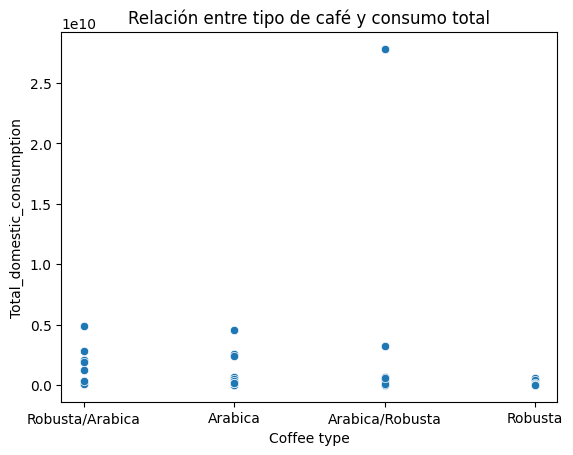

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Define la ruta del archivo
ruta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/Coffee_domestic_consumption.csv'

#carga el archivo en un DataFram
dataset = pd.read_csv(ruta)

#seaborn recibe la tabla de datos
sns.scatterplot(x='Coffee type', y='Total_domestic_consumption', data=dataset)

#arega un título al gráfico
plt.title('Relación entre tipo de café y consumo total')

#muestra el gráfico en pantalla
plt.show()

2b. Crear un gráfico de barras

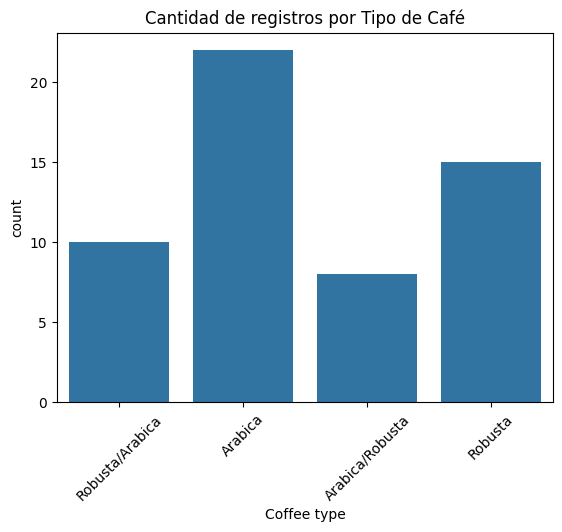

In [ ]:
#countplot indicando la columna de la categiríaen el eje X
sns.countplot(x='Coffee type', data=dataset)

#título
plt.title('Cantidad de registros por tipo de Café')

#Rotar letras para que no se amontonen
plt.xticks(rotation=45)

#mostrar el gráfico en pantalla
plt.show()

2c. Crear un histograma (histogram)

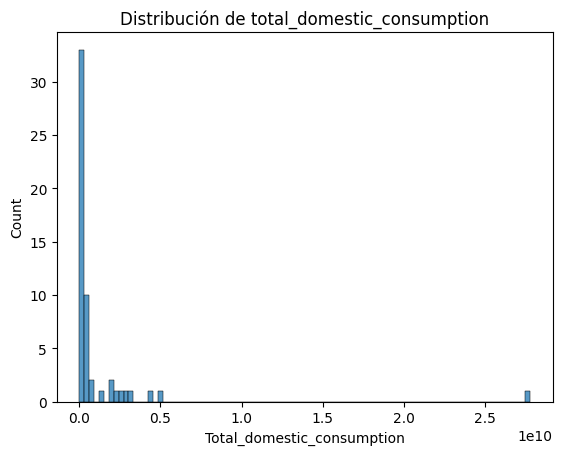

In [ ]:

ruta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/Coffee_domestic_consumption.csv'
dataset = pd.read_csv(ruta)
#Histplot indicando la columna numérica en el eje X
sns.histplot(x='Total_domestic_consumption', data=dataset)

#Título
plt.title('Distribución de Conumo doméstico ttal')

#Muestra el gráfico en pantalla
plt.show()

**¿Cómo se podría identificar el tipo de gráfico ideal para presentar información de un dataset?**

Para identificar el tipo de gráfico ideal, se debe considerar directamente el tipo de variables que se desean analizar. Si el objetivo es visualizar la distribución de una sola variable numérica, el gráfico ideal es el histograma. Si se busca observar la relación que existe entre dos variables numéricas,es más útil utilizar un diagrama de dispersión. Finalmente, cuando se necesita analizar variables cualitativas para realizar conteos y comparar cantidades entre diferentes categorías, la mejor opción es el gráfico de barras.



**Ejercicio 3: Complementar análisis numérico con gráficos en un dataset**

3a. Análisis de variables cuantitativas con su respectivo gráfico (histograma, dispersión)


Estadísticas del Consumo ---
count    5.500000e+01
mean     1.112487e+09
std      3.834783e+09
min      0.000000e+00
25%      9.586920e+06
50%      1.216200e+08
75%      5.897930e+08
max      2.782470e+10
Name: Total_domestic_consumption, dtype: float64


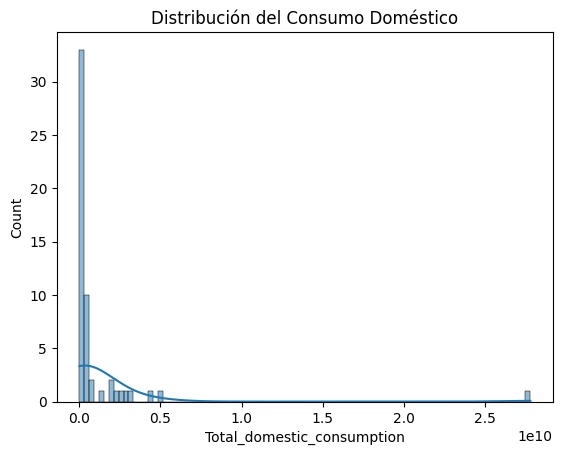

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/Coffee_domestic_consumption.csv'
dataset = pd.read_csv(ruta)

#análisis numérico
print("Estadísticas del Consumo ---")
print(dataset['Total_domestic_consumption'].describe())

#análisis visual
sns.histplot(x='Total_domestic_consumption', data=dataset, kde=True)
plt.title('Distribución del Consumo Doméstico')
plt.show()

3b. Análisis de variables cualitativas con su respectivo gráfico (barras, pieI)


Conteo por Tipo de Café
Coffee type
Arabica            22
Robusta            15
Robusta/Arabica    10
Arabica/Robusta     8
Name: count, dtype: int64


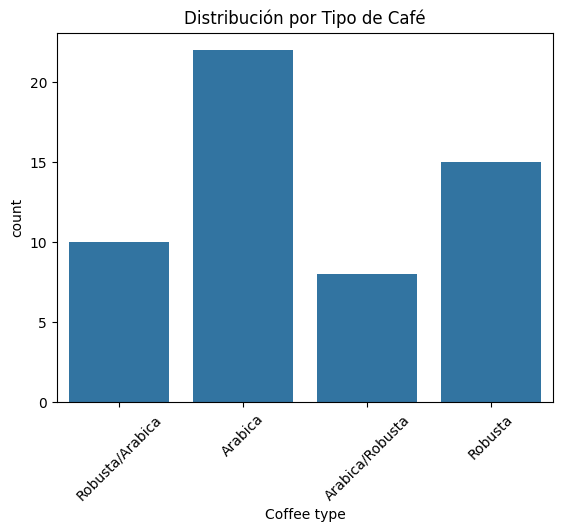

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta = '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/Coffee_domestic_consumption.csv'
dataset = pd.read_csv(ruta)

#conteo de categorías
print("Conteo por Tipo de Café")
conteo_categorias = dataset['Coffee type'].value_counts()
print(conteo_categorias)

#gráfico de barras)
sns.countplot(x='Coffee type', data=dataset)
plt.title('Distribución por Tipo de Café')
plt.xticks(rotation=45) #rota los nombres para que no se amontonen
plt.show()

**¿Tendría sentido incluir un Análisis Exploratorio de Datos en un pipeline de datos?**

En un pipeline de datos en producción, que suele ser un proceso automatizado , no tiene sentido incluir EDA completo, ya que este es un procedimiento manual y exploratorio. Aunque el EDA tradicional no forma parte como tal, sí se integran conceptos como las revisiones de calidad o el perfilado de datosautomatizado. Estas herramienta son esenciales dentro del pipeline para garantizar que la nueva información no ingrese corrupta o con valores que no esten en el rango

**Ejercicio 4: manejo de metadata**

1.a Uso de la línea de comandos para ver metadata

In [ ]:
!ls -l '/content/drive/MyDrive/Tercer semestre/Intro a datos/Archivos/Labs/'

total 20
-rw------- 1 root root   868 Apr 10 21:34 analisis_guardado.pkl
-rw------- 1 root root   161 Apr 10 13:57 campanas.csv
-rw------- 1 root root   161 Apr 10 16:22 campanas_pandas.csv
-rw------- 1 root root 14647 Apr 17 13:40 Coffee_domestic_consumption.csv
-rw------- 1 root root  1030 Apr 10 16:22 datos_campanas.pkl
-rw------- 1 root root    83 Apr 10 14:07 hola.txt
-rw------- 1 root root    46 Apr 10 14:21 nuevos_datos.csv
-rw------- 1 root root   100 Apr 10 14:21 reporte_final.txt


1.b Uso de Python para extraer metadata de un paquete

In [ ]:
from importlib import metadata

#define el paquete que se quiere investigar
nombre_paquete = 'pandas'

#extrae la versión específica
version = metadata.version(nombre_paquete)
print(f"Metadata Básica")
print(f"La versión instalada de {nombre_paquete} es: {version}\n")

#Extrae TODA la metadata del paquete (devuelve un dic)
info_completa = metadata.metadata(nombre_paquete)


print(f"Detalles del Paquete")
print(f"Nombre oficial: {info_completa['Name']}")
print(f"Resumen: {info_completa['Summary']}")
print(f"Autor/Contacto: {info_completa['Author-email']}")
print(f"Licencia: {info_completa['License']}")

Metadata Básica
La versión instalada de pandas es: 2.2.2

Detalles del Paquete
Nombre oficial: pandas
Resumen: Powerful data structures for data analysis, time series, and statistics
Autor/Contacto: The Pandas Development Team <pandas-dev@python.org>
Licencia: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names

**¿Cómo beneficiaría un buen manejo de metadata a un pipeline de datos?**

Un buen manejo de metadatos es importante en un PL de datos porque da un control operativo y técnico detallado sobre los procesos. Permite identificar si un archivo ya ha sido procesado, detectar si una entrega reciente está vacía analizando su tamaño, y mantener un registro de linaje para rastrear el origen exacto de cada dato.

**Ejercicio 5: página para portafolio**

https://sofiabilbaocr.github.io/Intro-a-datos/

El archivo ideal para un portafolio de datos es el Jupyter Notebook porque permiten intercalar bloques de texto explicativo, código de Python y resultados visuales en un documento fácil de leer.